# Exploratory Data Analysis (EDA) — Iris Dataset

**Internship Project | Data Science**

**Objective:** Analyze the classic Iris dataset to uncover patterns and trends using statistical summaries and visualizations, identify correlations and key influencing factors, and present the findings as a structured report.

**Dataset:** 150 samples of iris flowers across 3 species (*setosa*, *versicolor*, *virginica*), with 4 numeric features: `sepal_length`, `sepal_width`, `petal_length`, `petal_width`.

---
## 1. Setup & Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/iris.csv")
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Data Overview\n\nCheck shape, data types, and missing values before diving into analysis.

In [2]:
print("Shape:", df.shape)
df.info()


Shape: (150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [3]:
df.isnull().sum()


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

**Observation:** The dataset has 150 rows and 5 columns (4 numeric features + 1 categorical target). There are **no missing values**, so no imputation is required.

## 3. Class Balance\n\nChecking how many samples belong to each species.

In [4]:
df['species'].value_counts()


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

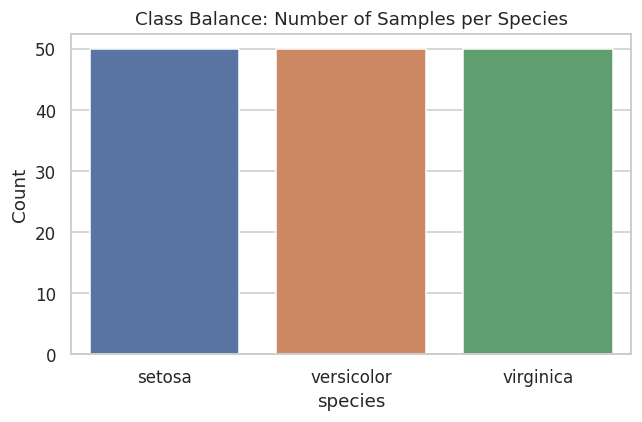

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='species', hue='species', legend=False)
plt.title('Class Balance: Number of Samples per Species')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Observation:** The dataset is perfectly balanced — 50 samples for each of the three species. This is ideal for both statistical comparison and any downstream classification modeling.

## 4. Statistical Summary\n\nOverall descriptive statistics, followed by a breakdown by species.

In [6]:
df.describe()


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.groupby('species').mean(numeric_only=True)


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [8]:
df.groupby('species').std(numeric_only=True)


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.352490,0.381024,0.173511,0.107210
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.635880,0.322497,0.551895,0.274650


**Observations:**
- *Setosa* is clearly the smallest-flowered species on petal dimensions (mean petal length ≈1.46 cm, petal width ≈0.24 cm).
- *Virginica* has the largest petals and sepals on average.
- *Versicolor* sits between the two on almost every measurement.
- Standard deviations show *setosa* is the most tightly clustered species (least internal variation), especially on petal measurements.

## 5. Correlation Analysis\n\nWhich features move together, and which are the strongest predictors of one another?

In [9]:
corr = df.drop(columns='species').corr(numeric_only=True)
corr


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


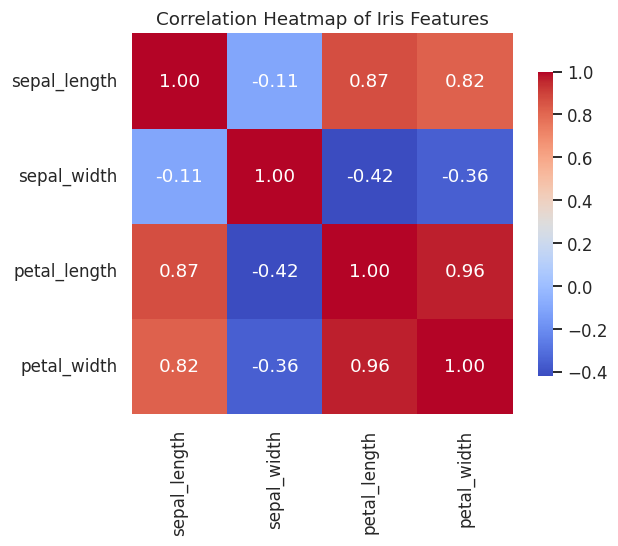

In [10]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={'shrink': .8})
plt.title('Correlation Heatmap of Iris Features')
plt.tight_layout()
plt.show()


**Key findings:**
- `petal_length` and `petal_width` are almost perfectly correlated (**r ≈ 0.96**) — the single strongest relationship in the dataset.
- `sepal_length` correlates strongly with both `petal_length` (**r ≈ 0.87**) and `petal_width` (**r ≈ 0.82**).
- `sepal_width` is only weakly, and *negatively*, correlated with the other three features — it behaves differently from the rest of the measurements and is the least useful feature for distinguishing species on its own.
- **Petal measurements are the key influencing factors** for separating species — far more than sepal measurements.

## 6. Feature Distributions

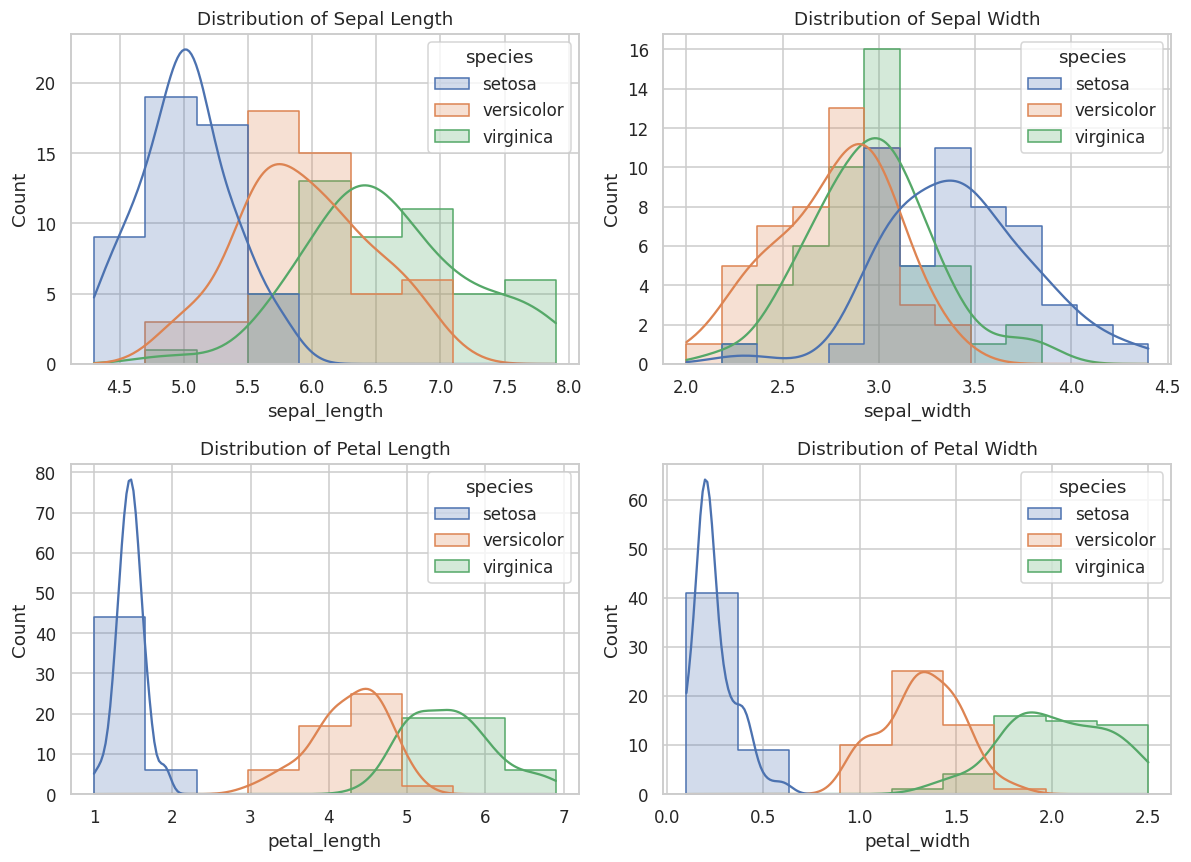

In [11]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.histplot(data=df, x=feat, hue='species', kde=True, ax=ax, element='step')
    ax.set_title(f"Distribution of {feat.replace('_',' ').title()}")
plt.tight_layout()
plt.show()


**Observation:** Petal length and petal width show clean, near-total separation between *setosa* and the other two species, with some overlap remaining between *versicolor* and *virginica*. Sepal width distributions overlap heavily across all three species.

## 7. Distributions by Species (Boxplots & Violin Plots)

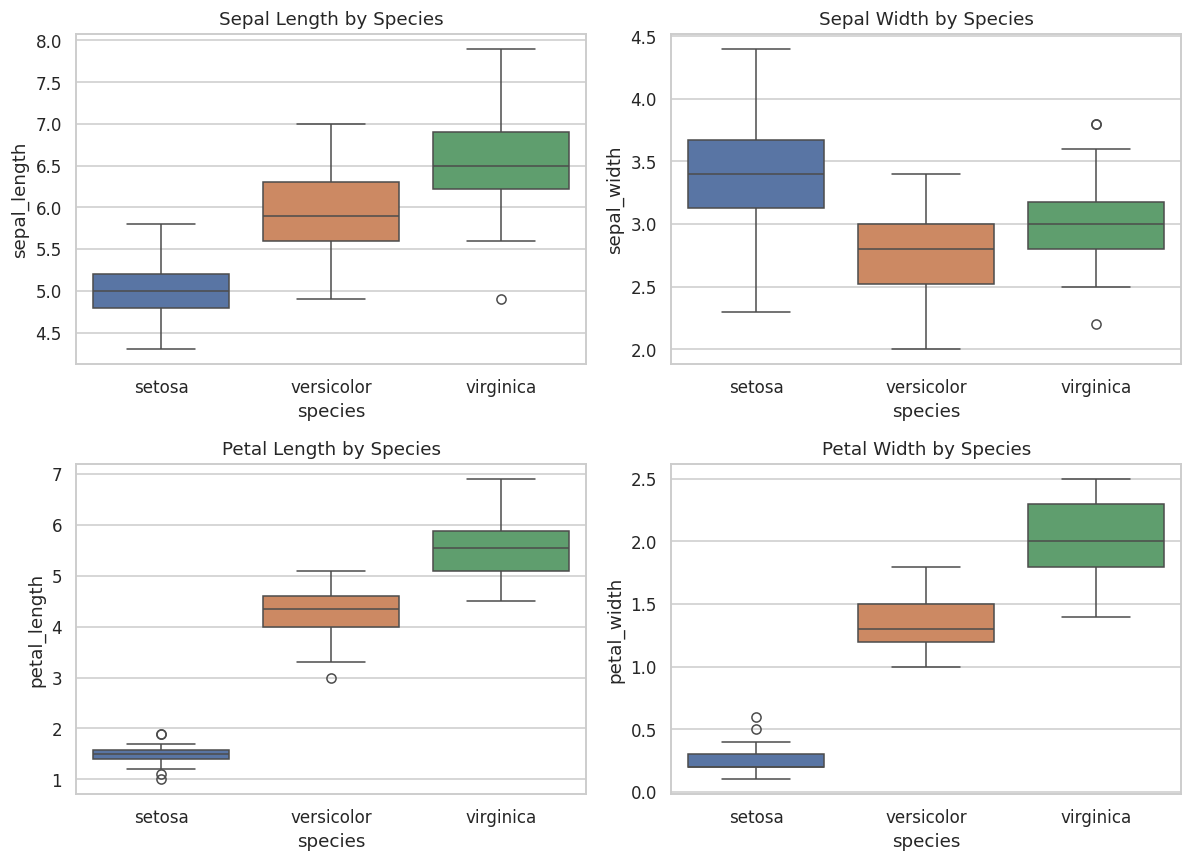

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='species', y=feat, ax=ax, hue='species', legend=False)
    ax.set_title(f"{feat.replace('_',' ').title()} by Species")
plt.tight_layout()
plt.show()


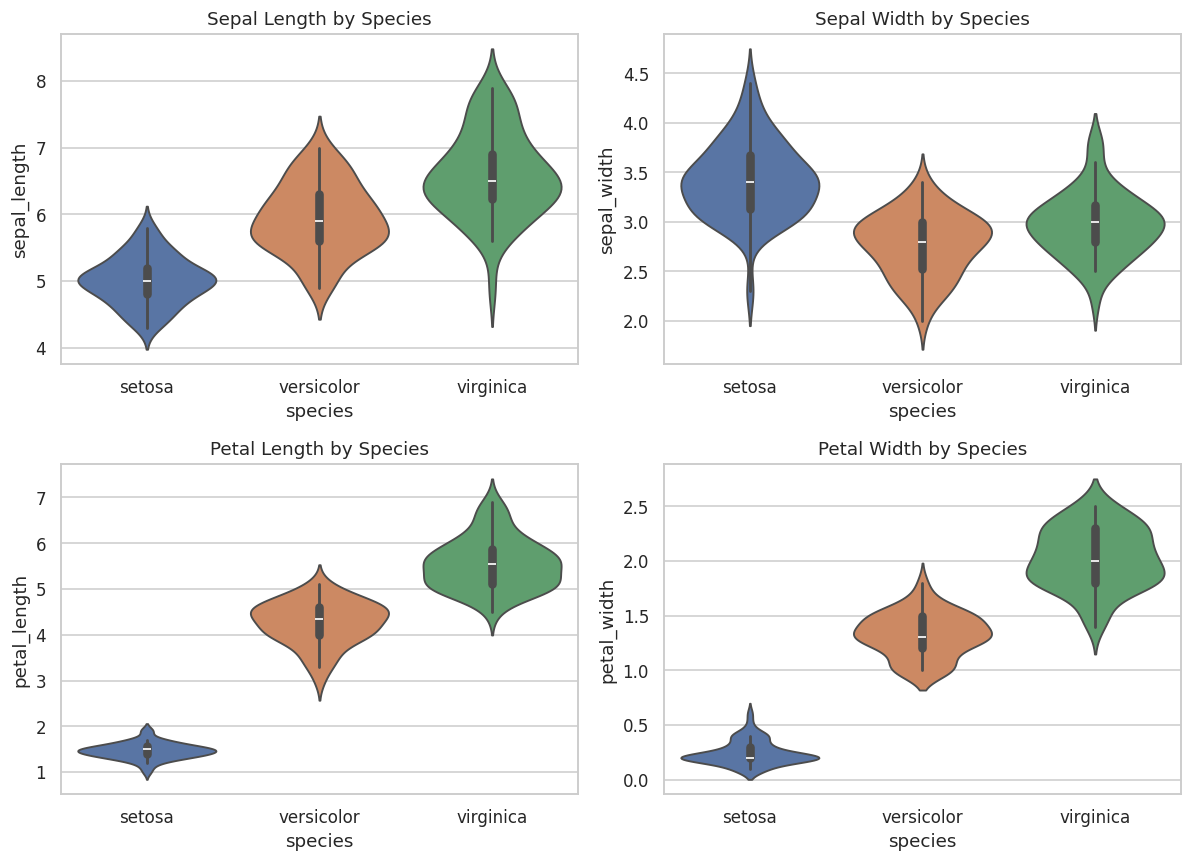

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.violinplot(data=df, x='species', y=feat, ax=ax, hue='species', legend=False)
    ax.set_title(f"{feat.replace('_',' ').title()} by Species")
plt.tight_layout()
plt.show()


**Observation:** Boxplots confirm minimal outliers overall. *Setosa* is a clear outlier group (in the statistical sense of being clearly separated) on petal measurements — it never overlaps with the other two species. *Versicolor* and *virginica* show some overlap, mainly on sepal width and sepal length.

## 8. Pairwise Relationships

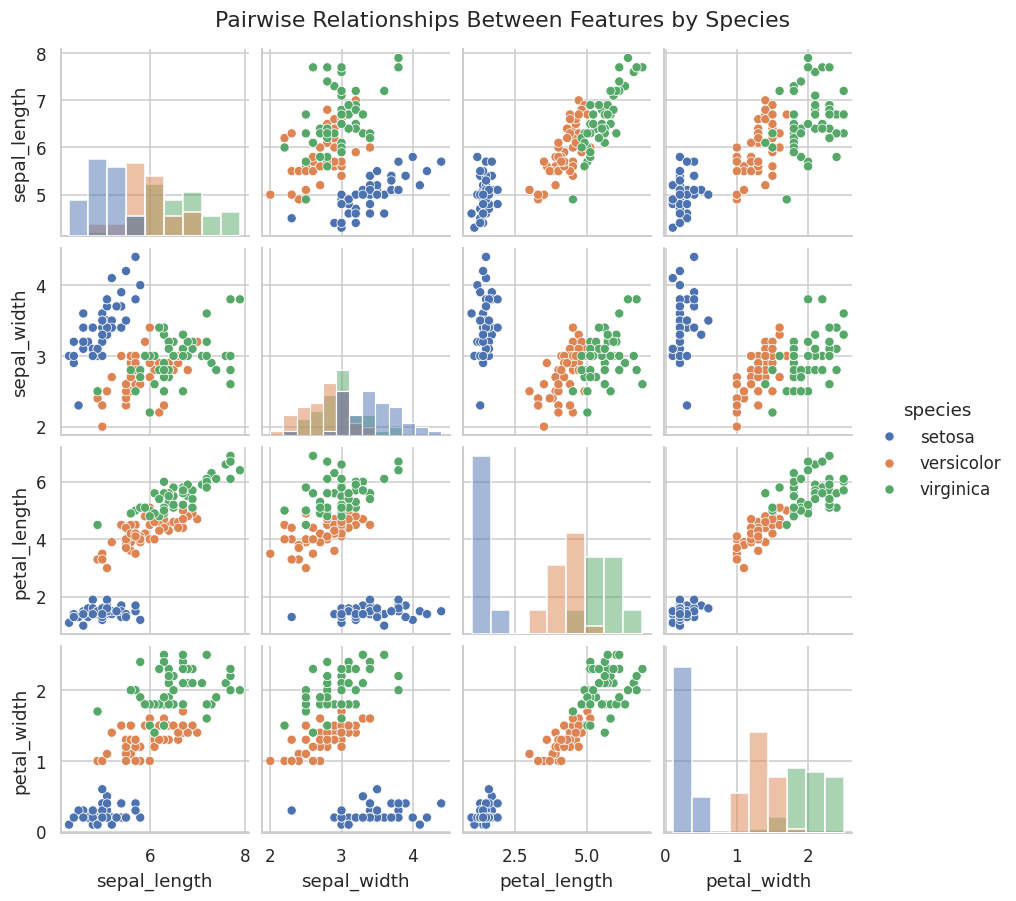

In [14]:
g = sns.pairplot(df, hue='species', diag_kind='hist', height=2.0)
g.fig.suptitle('Pairwise Relationships Between Features by Species', y=1.02)
plt.show()


**Observation:** The pairplot confirms that any scatterplot involving petal length or petal width shows near-perfect linear separation of *setosa* from the other two species, and a good (though imperfect) separation between *versicolor* and *virginica*.

## 9. Deep Dive: Petal Length vs Petal Width\n\nThe strongest correlated pair, and the best predictor of species.

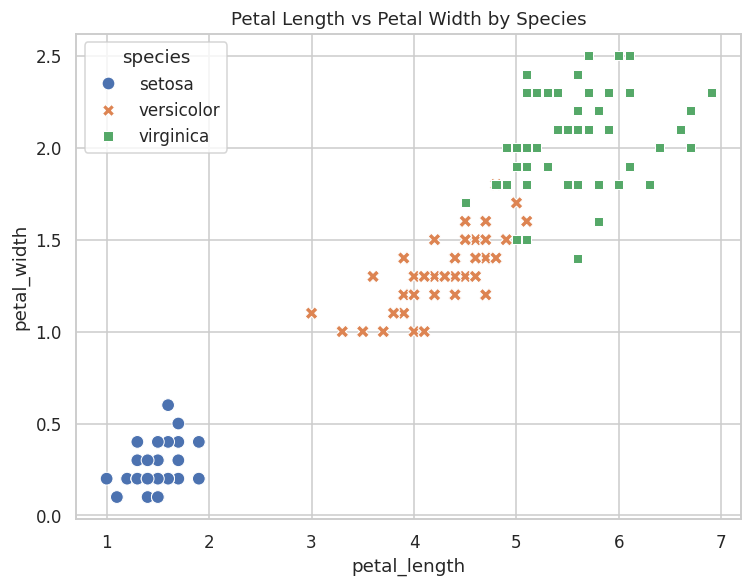

In [15]:
plt.figure(figsize=(7,5.5))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', style='species', s=70)
plt.title('Petal Length vs Petal Width by Species')
plt.tight_layout()
plt.show()


**Observation:** A simple threshold on petal length (~2.5 cm) alone would already separate *setosa* from the other two species with 100% accuracy. Petal width adds the extra separation needed between *versicolor* and *virginica*. This is why petal-based features are typically the top predictors in any Iris species classification model.

---
## 10. Summary of Key Insights

1. **No data cleaning was required** — the dataset has zero missing values and is perfectly balanced across the three species (50 samples each).
2. **Petal measurements (length & width) are the strongest influencing factors** for distinguishing species, with a near-perfect correlation of 0.96 between them.
3. **Setosa is easily separable** from the other two species using petal length/width alone — it forms a distinct, non-overlapping cluster.
4. **Versicolor and virginica overlap more**, particularly on sepal measurements, but remain reasonably distinguishable using petal features.
5. **Sepal width is the weakest / most independent feature**, showing weak-to-negative correlation with everything else, and is the least useful single feature for species separation.
6. These findings directly support why petal-based features dominate feature importance in classification models (e.g., Decision Trees, Random Forest, Logistic Regression) trained on this dataset.

## 11. Next Steps
- Build a classification model (Logistic Regression / Decision Tree / Random Forest) using petal features as primary predictors.
- Evaluate feature importance formally using a tree-based model to confirm the correlation-based findings above.
- Consider PCA to visualize the separability in 2D using all four features simultaneously.
